In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

> **نکتهٔ اجرا:** این نوت‌بوک برای اجرای **بالا به پایین** نوشته شده است. اگر خطای `NameError` دیدید، از **Kernel → Restart & Run All** استفاده کنید (یا ابتدا سلول importها را اجرا کنید).

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV,
    validation_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.decomposition import PCA

np.random.seed(42)


# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۳: حاشیهٔ نرم و ابرپارامترها

### در پایان این درس چه می‌آموزید
در پایان این درس باید بتوانید:

- توضیح دهید چرا **SVM با حاشیهٔ سخت** در حضور نویز یا دادهٔ غیرقابل‌تفکیک شکست می‌خورد.
- فرم **پرایمال حاشیهٔ نرم** با متغیرهای اسلک را استخراج کنید و نقش $C$ را از دید هندسی و آماری تفسیر کنید.
- ارتباط حاشیهٔ نرم را با **کمینه‌سازی ریسک تجربی منظم‌شده** و **زیان هینج** برقرار کنید.
- با استفاده از **پایپ‌لاین + اعتبارسنجی متقاطع**، $C$ و ابرپارامترهای کرنل مانند $\gamma$ (برای RBF)، `degree` (چندجمله‌ای) و `coef0` را تنظیم کنید.
- با **منحنی‌های اعتبارسنجی**، **تعداد بردارهای پشتیبان** و **رفتار مرز تصمیم** کم‌برازش/بیش‌برازش را تشخیص دهید.
- دام‌های رایج را بشناسید: **مقیاس‌بندی ویژگی‌ها**، **نشت داده**، **بایاس انتخاب** و **کالیبراسیون احتمال**.

در این نوت‌بوک از دو دیتاست (به‌صورت تصادفی انتخاب‌شده از مخزن شما) استفاده می‌کنیم:

- `../../../Datasets/Classification/iris.csv` (چندکلاسه، کوچک، نسبتاً تمیز)
- `../../../Datasets/Classification/diabetes.csv` (دودویی، نویزی، جدولی)

> نکته: در scikit-learn برای دسته‌بندی معمولاً از `SVC` (SVM کرنلی) یا `LinearSVC` (SVM خطی با حل‌گر متفاوت) استفاده می‌شود. ابرپارامترها کمی متفاوت‌اند، اما نقش مفهومی $C$ مشترک است.


---
## ۱. از حاشیهٔ سخت تا حاشیهٔ نرم: چرا به اسلک نیاز داریم

### ۱.۱ مرور حاشیهٔ سخت (حالت قابل‌تفکیک)
در حالت ایده‌آلِ خطیِ قابل‌تفکیک، SVM دودویی ابرصفحهٔ $(w,b)$ را با **بیشترین حاشیهٔ هندسی** پیدا می‌کند.

داده: $\{(x_i, y_i)\}_{i=1}^n$ که در آن $x_i \in \mathbb{R}^d$ و $y_i \in \{-1,+1\}$. تابع تصمیم: $f(x) = w^\top x + b$ و پیش‌بینی $\hat{y} = \mathrm{sign}(f(x))$.

قیود استاندارد $y_i(w^\top x_i + b)\ge 1$ را اعمال می‌کنیم. آنگاه:

$$
\begin{aligned}
\min_{w,b}\quad & \frac{1}{2}\lVert w\rVert^2 \\
\text{s.t.}\quad & y_i (w^\top x_i + b) \ge 1,\quad i=1,\dots,n.
\end{aligned}
$$

### ۱.۲ پهنای حاشیه برابر $2/\lVert w\rVert$ است (اثبات کوتاه)
دو ابرصفحهٔ پشتیبان را در نظر بگیرید:

- صفحهٔ حاشیهٔ مثبت: $w^\top x + b = +1$
- صفحهٔ حاشیهٔ منفی: $w^\top x + b = -1$

اگر $x_+$ روی صفحهٔ $+1$ و $x_-$ روی صفحهٔ $-1$ باشد، داریم:

$$
w^\top x_+ + b = 1,\qquad w^\top x_- + b = -1.
$$

تفاضل:

$$
w^\top(x_+ - x_-) = 2.
$$

فاصلهٔ دو صفحه در راستای نرمال، تصویر $(x_+-x_-)$ روی بردار نرمالِ واحد $w/\lVert w\rVert$ است:

$$
\text{dist} = \left(\frac{w}{\lVert w\rVert}\right)^\top (x_+-x_-) = \frac{w^\top(x_+-x_-)}{\lVert w\rVert} = \frac{2}{\lVert w\rVert}.
$$

پس کمینه کردن $\lVert w\rVert^2$ پهنای حاشیه را بیشینه می‌کند.

### ۱.۳ چرا حاشیهٔ سخت در عمل می‌شکند؟
دادهٔ واقعی معمولاً کاملاً قابل‌تفکیک نیست:

- برچسب‌ها ممکن است **نویز** داشته باشند،
- ویژگی‌ها ممکن است **ناکافی** باشند،
- **نقاط پرت** وجود دارد،
- فرایند اندازه‌گیری واریانس ایجاد می‌کند.

اگر حتی یک نقطه تفکیک‌پذیری را نقض کند، قیود حاشیهٔ سخت ناممکن می‌شوند. حاشیهٔ نرم با اجازه دادن به نقض‌های کنترل‌شده توسط **متغیرهای اسلک** این مشکل را حل می‌کند.


---
## ۲. SVM حاشیهٔ نرم: مسئلهٔ پرایمال با متغیرهای اسلک

### ۲.۱ متغیرهای اسلک و نقض حاشیه
متغیرهای $\xi_i \ge 0$ را معرفی می‌کنیم تا نقاط بتوانند حاشیه را نقض کنند:

- **بیرون حاشیه و درست**: $\xi_i = 0$ و $y_i(w^\top x_i + b) \ge 1$,
- **داخل حاشیه و درست**: $0 < \xi_i < 1$ و $0 < y_i(w^\top x_i + b) < 1$,
- **بدطبقه‌بندی‌شده**: $\xi_i \ge 1$ و $y_i(w^\top x_i + b) \le 0$.

فرم پرایمال حاشیهٔ نرم (اسلک L1):

$$
\begin{aligned}
\min_{w,b,\xi}\quad & \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \xi_i \\
\text{s.t.}\quad & y_i (w^\top x_i + b) \ge 1 - \xi_i,\quad i=1,\dots,n,\\
& \xi_i \ge 0,\quad i=1,\dots,n.
\end{aligned}
$$

### ۲.۲ پارامتر $C$ چه می‌کند؟
$C>0$ توازن را تعیین می‌کند:

- $C$ کوچک: نقض‌ها **ارزان** $\Rightarrow$ حاشیه پهن‌تر، منظم‌سازی بیشتر، بایاس بالاتر
- $C$ بزرگ: نقض‌ها **گران** $\Rightarrow$ حاشیه باریک‌تر، منظم‌سازی کمتر، واریانس بالاتر

### ۲.۳ نگاه روباست (نقاط پرت و نویز برچسب)
اگر برچسب‌ها اشتباه باشند، مجبور کردن مدل به فیت کردن آن‌ها (یعنی $C$ بسیار بزرگ) تعمیم را خراب می‌کند.
حاشیهٔ نرم یک مصالحهٔ کنترل‌شده است: شما «تفکیک کاملِ آموزش» را با «پایداری» معاوضه می‌کنید. در عمل:

- اگر **نویز برچسب** محتمل است، معمولاً $C$ را **خیلی بزرگ** نمی‌گیریم.
- اگر **ویژگی‌های نامربوط** زیاد دارید، مقیاس‌بندی و تنظیم دقیق $\gamma$ (برای RBF) حیاتی است.

### ۲.۴ حاشیهٔ نرم L1 در برابر L2 (اسلک مربعی)
یک نوع رایج از اسلک مربعی استفاده می‌کند:

$$
\min_{w,b,\xi}\ \frac{1}{2}\lVert w\rVert^2 + C \sum_i \xi_i^2\quad \text{s.t. } y_i(w^\top x_i+b)\ge 1-\xi_i,\ \xi_i\ge 0.
$$

این نوع نقض‌های بزرگ را شدیدتر جریمه می‌کند و تابع هدف نرم‌تری می‌دهد.
در scikit-learn، `LinearSVC` با `loss="squared_hinge"` به این نوع نزدیک است.


---
## ۳. حاشیهٔ نرم به‌عنوان کمینه‌سازی ریسک تجربی منظم‌شده

### ۳.۱ زیان هینج
زیان هینج را برای حاشیهٔ $m = y f(x)$ تعریف می‌کنیم:

$$
\ell_{\text{hinge}}(m) = \max(0, 1 - m).
$$

پس از حذف $\xi_i$ در بهینه، پرایمال (با صرف‌نظر از ضرایب مقیاس) به شکل زیر نوشته می‌شود:

$$
\min_{w,b}\ \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \max(0, 1 - y_i(w^\top x_i + b)).
$$

### ۳.۲ رابطهٔ $C$ و $\lambda$
در بسیاری از منابع:

$$
\min_{w,b}\ \frac{\lambda}{2}\lVert w\rVert^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i(w^\top x_i+b)).
$$

با هم‌ارزی از طریق مقیاس، داریم:

$$
\lambda = \frac{1}{nC}.
$$

### ۳.۳ زیرگرادیان‌ها (چرا بهینه‌سازی ویژه است)
زیان هینج محدب است اما در $m=1$ مشتق‌پذیر نیست. حل‌گرها از زیرگرادیان استفاده می‌کنند.
برای $m_i = y_i(w^\top x_i+b)$:

- اگر $m_i > 1$: زیرگرادیان صفر
- اگر $m_i < 1$: زیرگرادیان نسبت به $w$ برابر $-y_i x_i$ و نسبت به $b$ برابر $-y_i$
- اگر $m_i = 1$: هر ترکیب محدب بین $0$ و $-y_i x_i$ معتبر است

به همین دلیل بسیاری از پیاده‌سازی‌ها از طرح‌های بهینه‌سازی تخصصی استفاده می‌کنند (SMO، نزول مختصات و ...).


---
## ۴. نمای دوآل، بردارهای پشتیبان، و محل ورود کرنل‌ها

### ۴.۱ دوآل برای حاشیهٔ نرم L1 (نتیجهٔ کلیدی)
برای پرایمال حاشیهٔ نرم، دوآل به شکل زیر است:

$$
\begin{aligned}
\max_{\alpha}\quad & \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j y_i y_j x_i^\top x_j\\
\text{s.t.}\quad & 0 \le \alpha_i \le C,\ i=1,\dots,n,\\
& \sum_{i=1}^n \alpha_i y_i = 0.
\end{aligned}
$$

«نرمی» به صورت **قید جعبه‌ای** ظاهر می‌شود: $0 \le \alpha_i \le C$.

### ۴.۲ بردارهای پشتیبان با شرایط KKT
از ایستایی داریم $w = \sum_i \alpha_i y_i x_i$ و مکملیت KKT می‌گوید:

$$
\alpha_i\left(y_i(w^\top x_i+b)-1+\xi_i\right)=0.
$$

پس نقاطی که $\alpha_i>0$ دارند دقیقاً نقاطی هستند که حاشیه را لمس/نقض می‌کنند: **بردارهای پشتیبان**.
نکتهٔ تجربی: اگر تقریباً همهٔ نقاط بردار پشتیبان شوند، معمولاً مدل بیش‌ازحد منعطف است (مثلاً $\gamma$ بزرگ).

### ۴.۳ ترفند کرنل در دوآل
به جای ضرب داخلی از کرنل $K(x_i,x_j)$ استفاده می‌کنیم:

$$
x_i^\top x_j \ \longrightarrow\ K(x_i,x_j).
$$

تابع تصمیم:

$$
f(x) = \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b.
$$

فقط اندیس‌هایی با $\alpha_i>0$ مهم‌اند؛ بنابراین تعداد بردارهای پشتیبان روی زمان استنتاج اثر دارد.

### ۴.۴ ابرپارامترها داخل ماتریس کرنل زندگی می‌کنند
برای RBF:

$$
K(x,z) = \exp(-\gamma\lVert x-z\rVert^2).
$$

تغییر $\gamma$ کل ماتریس کرنل را تغییر می‌دهد و تعیین می‌کند کدام $\alpha_i$ها غیرصفر شوند.
برای کرنل چندجمله‌ای:

$$
K(x,z) = (\gamma x^\top z + \text{coef0})^{\text{degree}}.
$$

در اینجا `degree` مرتبهٔ چندجمله‌ای را کنترل می‌کند و `coef0` با شیفت دادن کرنل، سهم ترم‌های مرتبهٔ پایین/بالا را تغییر می‌دهد.


---
## ۵. راه‌اندازی عملی: ایمپورت‌ها، ابزارها، و گردش‌کار پایه

گردش‌کار ما:

1) بارگذاری داده از مسیرهای مخزن.
2) تقسیم آموزش/آزمون (یا CV).
3) ساخت `Pipeline` شامل پیش‌پردازش (اغلب مقیاس‌بندی) + مدل.
4) تنظیم ابرپارامترها با CV.
5) تحلیل رفتار با منحنی‌های اعتبارسنجی، آمار بردارهای پشتیبان، و تصویرسازی مرز تصمیم (در صورت امکان).


---
## ۶. دیتاست ۱ (انتخاب تصادفی): Iris — اثرات $C$ در یک محیط تمیز

فایل `iris.csv` ویژگی‌های پیوسته و برچسب `classification` دارد.

هرچند SVM ذاتاً دودویی است، scikit-learn برای `SVC` در حالت چندکلاسه به‌صورت داخلی روش one-vs-one را به کار می‌گیرد.
برای جدا کردن نقش $C$، ابتدا از SVM خطی شروع می‌کنیم.


In [3]:
iris_path = "../../../Datasets/Classification/iris.csv"
iris = pd.read_csv(iris_path)

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


### ۶.۱ بررسی‌های پایه
شکل داده، ستون‌ها، مقادیر گمشده و توزیع کلاس‌ها را بررسی می‌کنیم.


In [4]:
print("Shape:", iris.shape)
print("Columns:", list(iris.columns))

print("\nMissing values per column:")
print(iris.isna().sum())

print("\nClass distribution:")
print(iris["classification"].value_counts())

Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'classification']

Missing values per column:
sepal_length      0
sepal_width       0
petal_length      0
petal_width       0
classification    0
dtype: int64

Class distribution:
classification
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### ۶.۲ SVM خطی پایه همراه با مقیاس‌بندی

چون حاشیهٔ SVM به مقیاس ویژگی‌ها وابسته است، از استانداردسازی استفاده می‌کنیم:

$$
x' = \frac{x - \mu}{\sigma}.
$$

از `LinearSVC` (زیان هینج مربعی) استفاده می‌کنیم. در چندکلاسه، به‌طور پیش‌فرض one-vs-rest آموزش می‌دهد.


In [5]:
X_iris = iris.drop(columns=["classification"])
y_iris = iris["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris
)

pipe_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=1.0, kernel="linear"))
])

pipe_lin.fit(X_train, y_train)
pred = pipe_lin.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred))


Test accuracy: 0.9736842105263158

Classification report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



---
## ۷. ابرپارامتر $C$: منحنی اعتبارسنجی و رفتار بایاس–واریانس

یک منحنی اعتبارسنجی می‌سازیم: $C$ را روی شبکهٔ لگاریتمی تغییر می‌دهیم و دقت را با CV برآورد می‌کنیم.

چرا لگاریتمی؟ چون تغییر $C$ از $0.01$ به $0.1$ معمولاً اثر کیفی مشابه تغییر از $10$ به $100$ دارد.


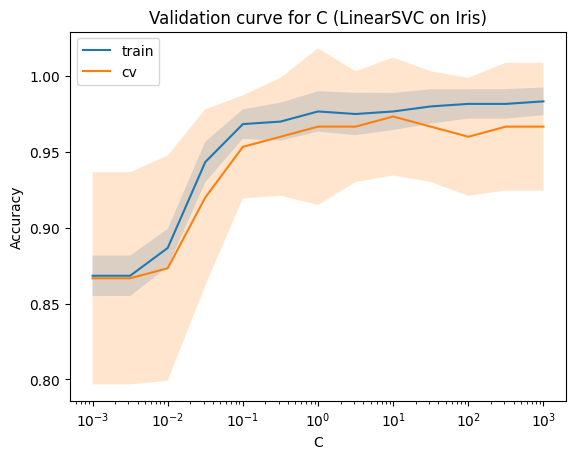

Best C by mean CV: 10.0 with CV accuracy: 0.9733333333333333


In [6]:
C_values = np.logspace(-3, 3, 13)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores, val_scores = validation_curve(
    pipe_lin,
    X_iris, y_iris,
    param_name="clf__C",
    param_range=C_values,
    cv=cv,
    scoring="accuracy",
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.semilogx(C_values, train_mean, label="train")
plt.fill_between(C_values, train_mean-train_std, train_mean+train_std, alpha=0.2)

plt.semilogx(C_values, val_mean, label="cv")
plt.fill_between(C_values, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation curve for C (LinearSVC on Iris)")
plt.legend()
plt.show()

best_idx = np.argmax(val_mean)
print("Best C by mean CV:", C_values[best_idx], "with CV accuracy:", val_mean[best_idx])

### ۷.۱ چگونه منحنی را بخوانیم
الگوهای رایج:

- $C$ بسیار کوچک: منظم‌سازی قوی $\Rightarrow$ کم‌برازش (امتیاز آموزش و CV پایین‌تر)
- $C$ بسیار بزرگ: فیت سخت‌تر روی آموزش؛ در دادهٔ نویزی CV می‌تواند افت کند (بیش‌برازش)
- نقطهٔ بهینه معمولاً یک **پلاتوی پهن** است نه یک قلهٔ تیز

توصیهٔ عملی: کوچک‌ترین $C$ را درون پلاتوی عملکرد بالا انتخاب کنید (مدل پایدارتر).


---
## ۸. تصویرسازی تعامل $C$ و $\gamma$ با کرنل RBF (PCA روی Iris)

برای نمایش، Iris را با PCA به ۲ بعد کاهش می‌دهیم و سپس SVMهای RBF مختلف را برای جفت‌های $(C,\gamma)$ آموزش می‌دهیم.
به نرمی/پیچیدگی مرز توجه کنید.

برای RBF:
- $\gamma$ کوچک $\Rightarrow$ نفوذ پهن و مرز نرم‌تر
- $\gamma$ بزرگ $\Rightarrow$ نفوذ بسیار محلی (خطر بیش‌برازش)

مرزهای تصمیم را در فضای PCA رسم می‌کنیم.


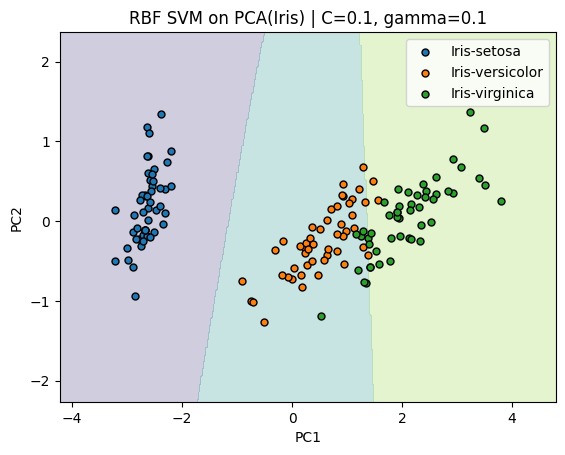

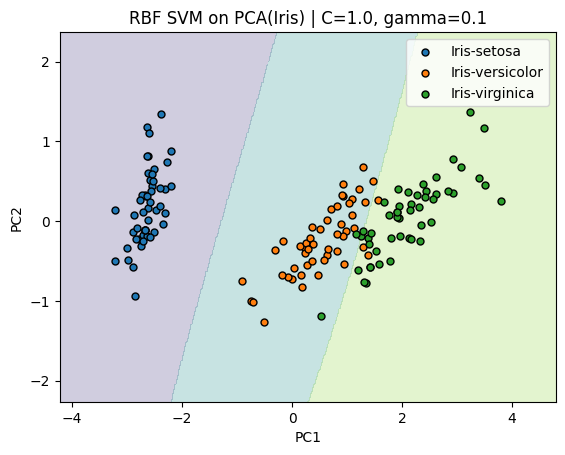

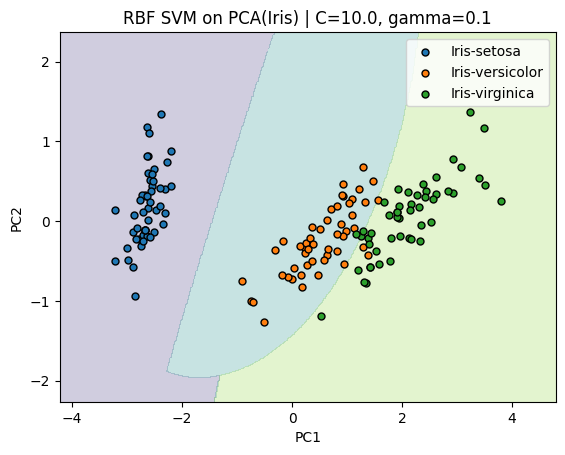

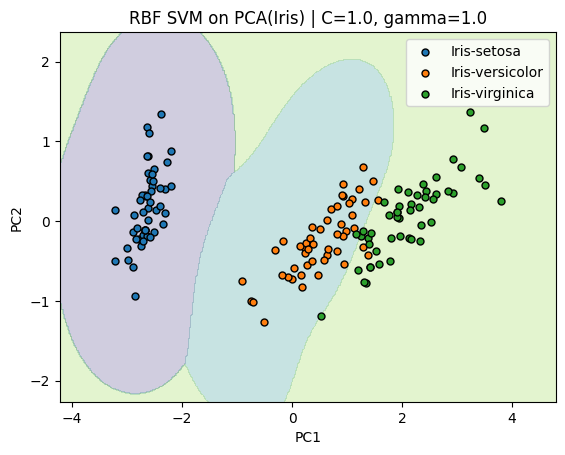

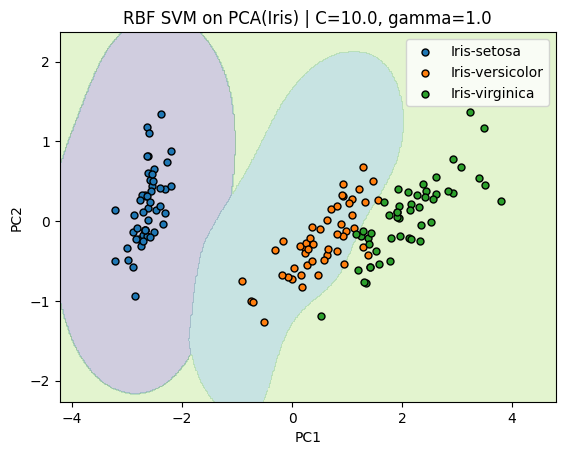

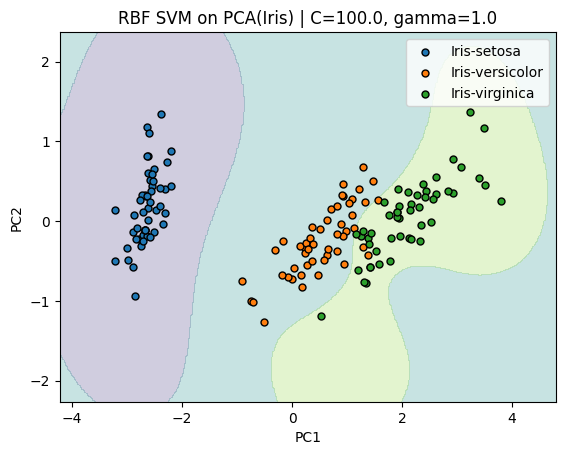

In [7]:
# PCA for visualization (Iris)
X2 = PCA(n_components=2, random_state=42).fit_transform(X_iris.values)

def plot_decision_regions(model, X2, y, title):
    le = LabelEncoder()
    le.fit(y)

    x_min, x_max = X2[:, 0].min() - 1.0, X2[:, 0].max() + 1.0
    y_min, y_max = X2[:, 1].min() - 1.0, X2[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_labels = model.predict(grid)
    Z = le.transform(Z_labels).reshape(xx.shape)

    plt.figure()
    levels = np.arange(len(le.classes_) + 1) - 0.5
    plt.contourf(xx, yy, Z, levels=levels, alpha=0.25)

    classes = le.classes_
    for c in classes:
        idx = (y == c)
        plt.scatter(X2[idx, 0], X2[idx, 1], s=25, label=c, edgecolor="k")

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

settings = [
    (0.1, 0.1),
    (1.0, 0.1),
    (10.0, 0.1),
    (1.0, 1.0),
    (10.0, 1.0),
    (100.0, 1.0),
]

y_np = y_iris.values
for C, gamma in settings:
    svm_rbf = SVC(C=C, kernel="rbf", gamma=gamma)
    svm_rbf.fit(X2, y_np)
    plot_decision_regions(svm_rbf, X2, y_np, title=f"RBF SVM on PCA(Iris) | C={C}, gamma={gamma}")


### ۸.۱ چک‌لیست تفسیر
وقتی ابرپارامترها را تغییر می‌دهید:

- نرمی مرز در برابر تکه‌تکه شدن نواحی
- حساسیت به تک‌نقطه‌ها (با $C$ بزرگ و $\gamma$ بزرگ بیشتر می‌شود)
- پایداری: تغییرات کوچک در داده نباید نواحی تصمیم را کاملاً تغییر دهد (برای مدل خوب منظم‌شده)

یادآوری: PCA فقط برای نمایش بود؛ تنظیم نهایی باید در فضای ویژگی‌های اصلی انجام شود.


---
## ۹. ابرپارامترهای کرنل چندجمله‌ای (شهود سریع)

حاشیهٔ نرم فقط $C$ نیست. در SVM کرنلی، پارامترهای کرنل می‌توانند ظرفیت مدل را غالباً تعیین کنند.

کرنل چندجمله‌ای:
$$
K(x,z) = (\gamma x^\top z + \text{coef0})^{\text{degree}}.
$$

نقش‌ها:
- `degree`: غیرخطی بودن را افزایش می‌دهد؛ درجات بالا سریع بیش‌برازش می‌کنند.
- `coef0`: کرنل را شیفت می‌دهد و نسبت سهم ترم‌های مرتبهٔ پایین/بالا را تغییر می‌دهد.
- `gamma`: ضرب داخلی را باز-مقیاس می‌کند (با مقیاس‌بندی ویژگی‌ها تعامل دارد).

یک جست‌وجوی شبکه‌ای کوچک روی Iris اجرا می‌کنیم.


In [8]:
# Polynomial kernel tuning on Iris (for hyperparameter intuition)
pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="poly"))
])

param_grid_poly = {
    "clf__C": np.logspace(-2, 2, 5),
    "clf__degree": [2, 3, 4, 5],
    "clf__gamma": ["scale", "auto"],
    "clf__coef0": [0.0, 0.5, 1.0],
}

grid_poly = GridSearchCV(
    pipe_poly,
    param_grid=param_grid_poly,
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=None,
    refit=True
)

grid_poly.fit(X_iris, y_iris)
print("Best poly params:", grid_poly.best_params_)
print("Best CV accuracy:", grid_poly.best_score_)

Best poly params: {'clf__C': np.float64(1.0), 'clf__coef0': 0.5, 'clf__degree': 2, 'clf__gamma': 'scale'}
Best CV accuracy: 0.9666666666666668


---
## ۱۰. دیتاست ۲ (انتخاب تصادفی): Diabetes — حاشیهٔ نرم در حضور نویز، مقیاس‌بندی، و معیارها

دیتاست دیابت دودویی است و ستون هدف `classification` دارد.
این دیتاست جای خوبی برای دیدن اهمیت مقیاس‌بندی و تنظیم ابرپارامترها است.


In [9]:
diab_path = "../../../Datasets/Classification/diabetes.csv"
diab = pd.read_csv(diab_path)

diab.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


### ۱۰.۱ بررسی‌های پایه


In [10]:
print("Shape:", diab.shape)
print("Columns:", list(diab.columns))

print("\nMissing values per column:")
print(diab.isna().sum())

print("\nTarget distribution:")
print(diab["classification"].value_counts())

Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'classification']

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
classification              0
dtype: int64

Target distribution:
classification
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64


### ۱۰.۲ SVM با کرنل RBF به‌عنوان خط پایه (همراه با مقیاس‌بندی)

از یک RBF SVM با `gamma="scale"` (هیوریستیک پیش‌فرض scikit-learn) شروع می‌کنیم.
در بسیاری از مسائل جدولی، این خط پایه بد نیست، اما به ندرت بهترین است.


In [11]:
X = diab.drop(columns=["classification"])
y = diab["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=1.0, kernel="rbf", gamma="scale", probability=False))
])

pipe_rbf.fit(X_train, y_train)
pred = pipe_rbf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))

Test accuracy: 0.765625

Classification report:
               precision    recall  f1-score   support

    Diabetic       0.73      0.52      0.61        67
Non-Diabetic       0.78      0.90      0.83       125

    accuracy                           0.77       192
   macro avg       0.75      0.71      0.72       192
weighted avg       0.76      0.77      0.75       192


Confusion matrix:
 [[ 35  32]
 [ 13 112]]


---
## ۱۱. مقیاس‌بندی ویژگی‌ها از $\gamma$ جدا نیست (پس از ظرفیت مدل هم جدا نیست)

در کرنل RBF، فاصله‌ها نقش مرکزی دارند:
$$
\lVert x-z\rVert^2 = \sum_{k=1}^d (x_k - z_k)^2.
$$

اگر یک ویژگی مقیاس عددی بسیار بزرگ‌تری داشته باشد، فاصله‌ها را غالب می‌کند و عملاً کرنل را کنترل می‌کند.
این باعث می‌شود $\gamma$ «معنا»ی دیگری پیدا کند. در واقع اگر همهٔ ویژگی‌ها را در ثابت $s$ ضرب کنیم:

$$
\lVert s x - s z\rVert^2 = s^2 \lVert x-z\rVert^2
\quad\Rightarrow\quad
\exp(-\gamma s^2 \lVert x-z\rVert^2) = \exp(-(\gamma s^2)\lVert x-z\rVert^2).
$$

پس باز-مقیاس کردن ویژگی‌ها معادل باز-مقیاس کردن $\gamma$ به اندازهٔ $s^2$ است.
به همین دلیل مقیاس‌بندی و $\gamma$ را یک انتخابِ جفت‌شده می‌دانیم.

یک مقایسهٔ سادهٔ با/بدون مقیاس‌بندی انجام می‌دهیم.


In [12]:
# Compare with and without scaling (Diabetes)
svm_no_scale = SVC(C=1.0, kernel="rbf", gamma="scale")
svm_no_scale.fit(X_train, y_train)
pred_ns = svm_no_scale.predict(X_test)

pipe_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=1.0, kernel="rbf", gamma="scale"))
])
pipe_scaled.fit(X_train, y_train)
pred_sc = pipe_scaled.predict(X_test)

print("Accuracy without scaling:", accuracy_score(y_test, pred_ns))
print("Accuracy with scaling:", accuracy_score(y_test, pred_sc))

Accuracy without scaling: 0.7395833333333334
Accuracy with scaling: 0.765625


---
## ۱۲. چرا دقت کافی نیست؛ استفاده از ROC-AUC با نمرهٔ تصمیم

دقت به آستانه وابسته است (آستانهٔ ضمنی ۰ برای نمرهٔ تصمیم) و می‌تواند خطاهای نامتقارن را پنهان کند.
ROC-AUC از رتبه‌بندی نمره‌ها استفاده می‌کند و اغلب پایدارتر است.

در SVM می‌توان از:
- `.decision_function(X)` به عنوان نمرهٔ پیوسته
- یا احتمال‌های کالیبره‌شده (از طریق `probability=True` یا کالیبراسیون خارجی)

ROC-AUC را با نمرهٔ تصمیم محاسبه می‌کنیم.


ROC-AUC (decision scores): 0.18614925373134325


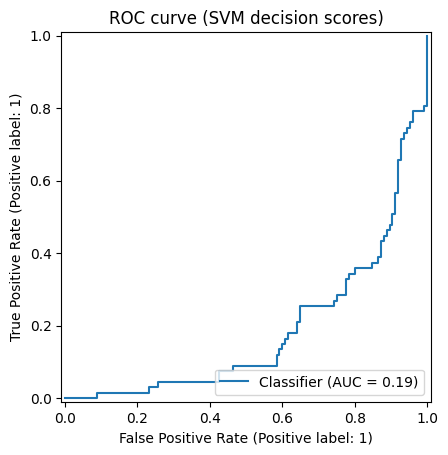

In [13]:
scores = pipe_rbf.decision_function(X_test)
y_true = (y_test == "Diabetic").astype(int)

auc = roc_auc_score(y_true, scores)
print("ROC-AUC (decision scores):", auc)

RocCurveDisplay.from_predictions(y_true, scores)
plt.title("ROC curve (SVM decision scores)")
plt.show()

---
## ۱۳. تنظیم ابرپارامتر برای RBF SVM: جست‌وجوی مشترک روی $(C,\gamma)$

### ۱۳.۱ چرا مشترک؟
$C$ و $\gamma$ با هم تعامل دارند. شهود:

- افزایش $\gamma$ کرنل را محلی‌تر می‌کند (انعطاف بیشتر)
- افزایش $C$ نقض‌ها را گران‌تر می‌کند (فیت سخت‌تر)
- ترکیب $\gamma$ بزرگ و $C$ بزرگ بیشترین خطر بیش‌برازش را دارد

از شبکهٔ لگاریتمی و ROC-AUC در CV استفاده می‌کنیم.


In [14]:
# Custom scoring callable: signature (estimator, X, y)
def auc_scorer(estimator, X_val, y_val):
    scores = estimator.decision_function(X_val)
    y_bin = (np.asarray(y_val) == "Diabetic").astype(int)
    return roc_auc_score(y_bin, scores)

param_grid = {
    "clf__C": np.logspace(-2, 3, 6),        # 1e-2 ... 1e3
    "clf__gamma": np.logspace(-3, 1, 5),    # 1e-3 ... 1e1
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_rbf,
    param_grid=param_grid,
    scoring=auc_scorer,
    cv=cv,
    n_jobs=None,
    refit=True,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_
test_scores = best_model.decision_function(X_test)
test_auc = roc_auc_score(y_true, test_scores)
print("Test ROC-AUC:", test_auc)


Best params: {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}
Best CV ROC-AUC: 0.29199837398373985
Test ROC-AUC: 0.2847761194029851


### ۱۳.۲ بررسی سطح جست‌وجو
با نگاه به نتایج CV می‌توان فهمید بهترین تنظیم از یک ناحیهٔ پایدار آمده یا یک قلهٔ تصادفی است.
اگر امتیاز بین نقاط مجاور شبکه شدیداً نوسان کند، احتمالاً در رژیم واریانس بالا هستید یا داده/ویژگی کافی ندارید.


In [15]:
results = pd.DataFrame(grid.cv_results_)
cols = ["param_clf__C", "param_clf__gamma", "mean_test_score", "std_test_score", "mean_train_score"]
results[cols].sort_values("mean_test_score", ascending=False).head(12)

,param_clf__C,param_clf__gamma,mean_test_score,std_test_score,mean_train_score
27,1000.00,0.1,0.291998,0.030396,0.000497
14,1.00,10.0,0.291246,0.026527,0.000000
19,10.00,10.0,0.291180,0.026574,0.000000
24,100.00,10.0,0.291180,0.026574,0.000000
29,1000.00,10.0,0.291180,0.026574,0.000000
9,0.10,10.0,0.290846,0.026635,0.000000
4,0.01,10.0,0.290380,0.027754,0.000000
23,100.00,1.0,0.275618,0.014491,0.000000
28,1000.00,1.0,0.275618,0.014491,0.000000
18,10.00,1.0,0.275085,0.014920,0.000000


---
## ۱۴. تحلیل نقش $C$ با تعداد بردارهای پشتیبان

یک ابزار تشخیصی: تعداد بردارهای پشتیبان را با تغییر $C$ (و ثابت نگه داشتن $\gamma$) دنبال کنید.

چرا مفید است؟
- بردار پشتیبان بیشتر یعنی مرز به نقاط بیشتری وابسته است (ممکن است پیچیده‌تر باشد)
- بردار پشتیبان کمتر می‌تواند مرز ساده‌تر را نشان دهد (ولی شاید هم بیش از حد صلب باشد)
- در SVM کرنلی، هزینهٔ پیش‌بینی با تعداد بردارهای پشتیبان رشد می‌کند

نمودار تعداد SV بر حسب $C$ و همچنین ROC-AUC تست بر حسب $C$ را رسم می‌کنیم.


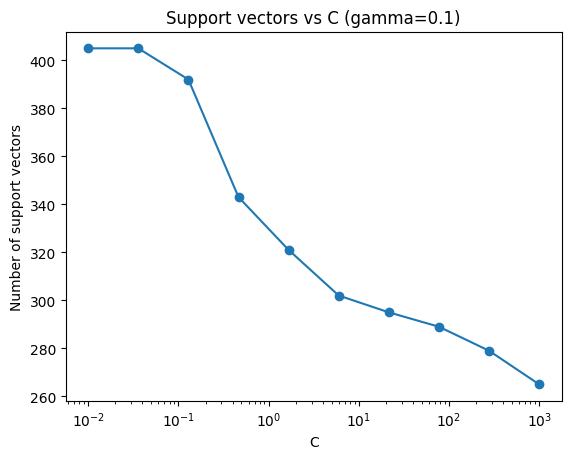

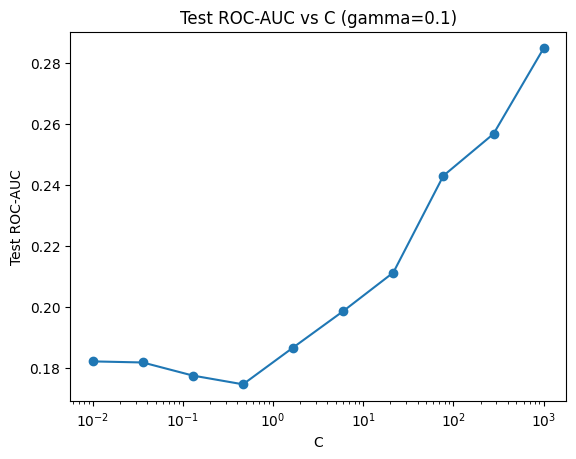

In [16]:
C_values = np.logspace(-2, 3, 10)
gamma_fixed = 0.1

sv_counts = []
test_auc_list = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=C, kernel="rbf", gamma=gamma_fixed))
    ])
    model.fit(X_train, y_train)
    n_sv = model.named_steps["clf"].n_support_.sum()
    sv_counts.append(n_sv)
    
    scores = model.decision_function(X_test)
    auc = roc_auc_score(y_true, scores)
    test_auc_list.append(auc)

plt.figure()
plt.semilogx(C_values, sv_counts, marker="o")
plt.xlabel("C")
plt.ylabel("Number of support vectors")
plt.title(f"Support vectors vs C (gamma={gamma_fixed})")
plt.show()

plt.figure()
plt.semilogx(C_values, test_auc_list, marker="o")
plt.xlabel("C")
plt.ylabel("Test ROC-AUC")
plt.title(f"Test ROC-AUC vs C (gamma={gamma_fixed})")
plt.show()

---
## ۱۵. نامتوازنی کلاس و $C$ مؤثر برای هر کلاس (`class_weight`)

حاشیهٔ نرم را می‌توان به‌ازای کلاس‌ها وزن‌دهی کرد. به صورت مفهومی شبیه استفاده از $C_+$ و $C_-$ متفاوت است.
اگر کلاس مثبت کمیاب باشد (یا از دست دادن آن هزینهٔ زیادی داشته باشد)، می‌توان خطای آن را گران‌تر کرد.

در scikit-learn: `class_weight="balanced"` وزن‌ها را معکوس فراوانی کلاس‌ها تنظیم می‌کند.
تنظیم پیش‌فرض و balanced را با $(C,\gamma)$ تیون‌شده مقایسه می‌کنیم.


ROC-AUC default: 0.2847761194029851
ROC-AUC balanced: 0.29337313432835826


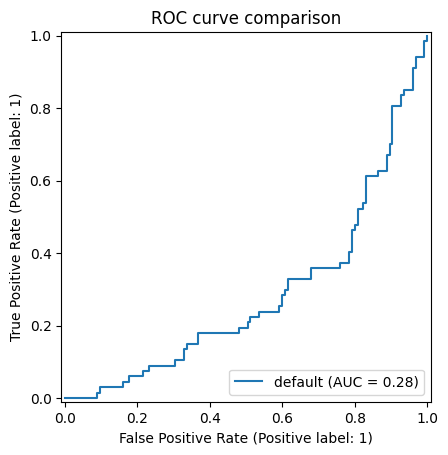

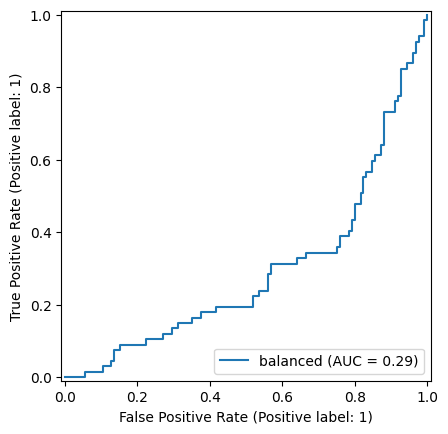

In [17]:
pipe_default = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=grid.best_params_["clf__C"], gamma=grid.best_params_["clf__gamma"], kernel="rbf"))
])

pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=grid.best_params_["clf__C"], gamma=grid.best_params_["clf__gamma"], kernel="rbf",
                class_weight="balanced"))
])

pipe_default.fit(X_train, y_train)
pipe_balanced.fit(X_train, y_train)

scores_default = pipe_default.decision_function(X_test)
scores_balanced = pipe_balanced.decision_function(X_test)

auc_default = roc_auc_score(y_true, scores_default)
auc_balanced = roc_auc_score(y_true, scores_balanced)

print("ROC-AUC default:", auc_default)
print("ROC-AUC balanced:", auc_balanced)

RocCurveDisplay.from_predictions(y_true, scores_default, name="default")
plt.title("ROC curve comparison")
RocCurveDisplay.from_predictions(y_true, scores_balanced, name="balanced")
plt.show()

---
## ۱۶. جست‌وجوی تصادفی: وقتی جست‌وجوی شبکه‌ای اتلاف می‌شود

جست‌وجوی شبکه‌ای با افزایش تعداد پارامترها به‌صورت نمایی بزرگ می‌شود و ممکن است آزمون‌های زیادی را در نواحی بد تلف کند.
جست‌وجوی تصادفی اغلب سریع‌تر ناحیهٔ خوب را پیدا می‌کند، مخصوصاً وقتی فقط چند پارامتر واقعاً مهم باشند.

رویکرد استاندارد:
1) جست‌وجوی تصادفی در بازه‌های وسیع
2) سپس یک شبکهٔ پالایش‌شده نزدیک ناحیهٔ بهتر

۳۰ تکرار جست‌وجوی تصادفی روی بازه‌های لگاریتمی اجرا می‌کنیم.


In [18]:
# Randomized search (often more efficient than grid for wide ranges)
try:
    from scipy.stats import loguniform
    C_dist = loguniform(1e-3, 1e3)
    gamma_dist = loguniform(1e-4, 1e1)
except Exception:
    # Fallback: approximate log-uniform using exponent sampling
    class _LogUniform:
        def __init__(self, a, b):
            self.a, self.b = a, b
        def rvs(self, size=None, random_state=None):
            rng = np.random.RandomState(random_state)
            return 10 ** rng.uniform(np.log10(self.a), np.log10(self.b), size=size)
    C_dist = _LogUniform(1e-3, 1e3)
    gamma_dist = _LogUniform(1e-4, 1e1)

param_dist = {"clf__C": C_dist, "clf__gamma": gamma_dist}

rand = RandomizedSearchCV(
    estimator=pipe_rbf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=auc_scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=None,
    refit=True,
    return_train_score=True
)

rand.fit(X_train, y_train)

print("Best params (random search):", rand.best_params_)
print("Best CV ROC-AUC:", rand.best_score_)

test_scores = rand.best_estimator_.decision_function(X_test)
print("Test ROC-AUC:", roc_auc_score(y_true, test_scores))

Best params (random search): {'clf__C': np.float64(0.0013289448722869186), 'clf__gamma': np.float64(7.072114131472227)}
Best CV ROC-AUC: 0.28744878048780487
Test ROC-AUC: 0.30071641791044773


---
## ۱۷. بایاس انتخاب و nested cross-validation (مهم برای گزارش)

اگر ابرپارامترها را تیون کنید و همان امتیاز CV را گزارش کنید، در واقع به دادهٔ اعتبارسنجی «نگاه» کرده‌اید.
این باعث خوش‌بینی در برآورد می‌شود.

nested CV این مشکل را حل می‌کند:
- CV داخلی ابرپارامترها را انتخاب می‌کند
- CV بیرونی تعمیم‌پذیری را روی فولدهای دیده‌نشده می‌سنجد

خروجی یک توزیع از امتیازها است (میانگین ± انحراف معیار) که صادقانه‌تر و مفیدتر است.


In [19]:
# Nested CV for an unbiased performance estimate after tuning
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

outer_scores = []
outer_best_params = []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    y_te_bin = (y_te == "Diabetic").astype(int)
    
    inner_grid = GridSearchCV(
        estimator=pipe_rbf,
        param_grid=param_grid,
        scoring=auc_scorer,
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=fold),
        n_jobs=None,
        refit=True
    )
    inner_grid.fit(X_tr, y_tr)
    best = inner_grid.best_estimator_
    
    scores = best.decision_function(X_te)
    auc = roc_auc_score(y_te_bin, scores)
    
    outer_scores.append(auc)
    outer_best_params.append(inner_grid.best_params_)
    print(f"Fold {fold}: AUC={auc:.4f}, best={inner_grid.best_params_}")

print("\nNested CV AUC mean:", float(np.mean(outer_scores)))
print("Nested CV AUC std:", float(np.std(outer_scores)))
print("\nBest params per fold:", outer_best_params)

Fold 1: AUC=0.2317, best={'clf__C': np.float64(0.01), 'clf__gamma': np.float64(10.0)}
Fold 2: AUC=0.3070, best={'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}
Fold 3: AUC=0.3631, best={'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}
Fold 4: AUC=0.2817, best={'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}
Fold 5: AUC=0.2598, best={'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}

Nested CV AUC mean: 0.2886722571628232
Nested CV AUC std: 0.04475523021941347

Best params per fold: [{'clf__C': np.float64(0.01), 'clf__gamma': np.float64(10.0)}, {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}, {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}, {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}, {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}]


---
## ۱۸. برآورد احتمال و کالیبراسیون (حاشیهٔ نرم برابر احتمال نیست)

نمرهٔ تصمیم SVM احتمال نیست.
برای بسیاری از کاربردها (امتیازدهی ریسک، تصمیم‌گیری، آستانه‌های حساس به هزینه) احتمال‌های کالیبره‌شده مفیدند.

یک روش رایج Platt scaling (کالیبراسیون سیگموید) است. در scikit-learn، `CalibratedClassifierCV` می‌تواند هر طبقه‌بند را با CV کالیبره کند.
ما:

- یک SVM کالیبره‌شده فیت می‌کنیم
- Brier score را محاسبه می‌کنیم (کمتر بهتر)
- نمودار قابلیت اعتماد (reliability diagram) را رسم می‌کنیم

نکته: این کار لزوماً قاعدهٔ جداسازی را زیاد تغییر نمی‌دهد، اما تفسیر نمره‌ها را تغییر می‌دهد.


Brier score: 0.1985617709708223


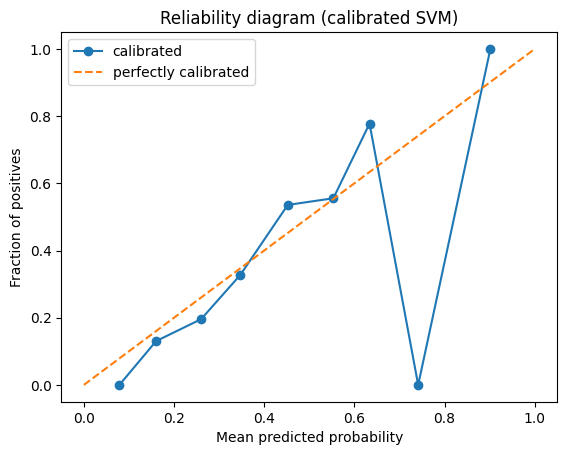

In [20]:
# Probability calibration for SVM (sigmoid/Platt scaling) using cross-validation
base_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(C=grid.best_params_["clf__C"], gamma=grid.best_params_["clf__gamma"], kernel="rbf"))
])

cal = CalibratedClassifierCV(estimator=base_svm, method="sigmoid", cv=5)
cal.fit(X_train, y_train)

# calibrated probabilities for the positive class "Diabetic"
proba = cal.predict_proba(X_test)[:, list(cal.classes_).index("Diabetic")]
y_bin = (y_test == "Diabetic").astype(int)

print("Brier score:", brier_score_loss(y_bin, proba))

frac_pos, mean_pred = calibration_curve(y_bin, proba, n_bins=10, strategy="uniform")

plt.figure()
plt.plot(mean_pred, frac_pos, marker="o", label="calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", label="perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability diagram (calibrated SVM)")
plt.legend()
plt.show()


---
## ۱۹. تمرین‌ها و پاسخ‌ها

### تمرین ۱ (هندسه)
اثبات کنید فاصلهٔ بین ابرصفحه‌های $w^\top x+b=1$ و $w^\top x+b=-1$ برابر $2/\lVert w\rVert$ است.

#### پاسخ
این موضوع در بخش ۱.۲ با تصویر کردن بردار بین صفحات روی جهت نرمالِ واحد $w/\lVert w\rVert$ نشان داده شد.

---

### تمرین ۲ (هم‌ارزی زیان هینج)
نشان دهید در بهینه، $\xi_i^\star = \max(0, 1 - y_i(w^\top x_i+b))$ و تابع هدف به فرم منظم‌سازی + زیان هینج تبدیل می‌شود.

#### پاسخ (طرح)
از قیود داریم $\xi_i \ge 1-y_if(x_i)$ و $\xi_i\ge 0$، پس $\xi_i \ge \max(0,1-y_if(x_i))$.
چون تابع هدف با $\xi_i$ افزایش می‌یابد، در بهینه کوچک‌ترین مقدار مجاز انتخاب می‌شود و همین عبارت max به دست می‌آید.
با جایگذاری در پرایمال، فرم زیان هینج به دست می‌آید.

---

### تمرین ۳ (شهود دوآل)
توضیح دهید چرا افزایش $C$ می‌تواند حساسیت به نقاط پرت را بیشتر کند، با استفاده از قید دوآل $0\le \alpha_i \le C$.

#### پاسخ (بحث)
در دوآل، اثر هر نقطه با $\alpha_i$ کنترل می‌شود. بزرگ‌تر شدن $C$ اجازه می‌دهد $\alpha_i$ بزرگ‌تر شود، بنابراین نقاط پرت یا برچسب‌خوردهٔ اشتباه می‌توانند اثر بیشتری روی تابع تصمیم بگذارند. این می‌تواند روباستی حاشیه را کم کند و تعمیم را بدتر کند.

---

### تمرین ۴ (عملی)
روی دیتاست دیابت، یک جست‌وجوی شبکه‌ای روی $C$ و $\gamma$ انجام دهید و گزارش کنید:
1) بهترین ROC-AUC در CV
2) ROC-AUC روی تست
3) بهترین ابرپارامترها

#### پاسخ (کد)
این نوت‌بوک این کار را با `grid` انجام داده است. سلول زیر نتایج را چاپ می‌کند.


In [21]:
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_
test_scores = best_model.decision_function(X_test)
test_auc = roc_auc_score(y_true, test_scores)
print("Test ROC-AUC:", test_auc)

Best params: {'clf__C': np.float64(1000.0), 'clf__gamma': np.float64(0.1)}
Best CV ROC-AUC: 0.29199837398373985
Test ROC-AUC: 0.2847761194029851


---
### تمرین ۵ (مقیاس‌بندی و $\gamma$)
فرض کنید همهٔ ویژگی‌ها را در $s>0$ ضرب می‌کنید. نشان دهید SVM با RBF و پارامتر $\gamma$ روی دادهٔ مقیاس‌بندی‌شده معادل SVM با پارامتر $\gamma s^2$ روی دادهٔ اصلی است (با ثابت بودن $C$).

#### پاسخ
برای هر زوج $x,z$:
$$
\lVert sx - sz\rVert^2 = s^2\lVert x-z\rVert^2.
$$
پس:
$$
\exp(-\gamma\lVert sx-sz\rVert^2) = \exp(-\gamma s^2 \lVert x-z\rVert^2).
$$
بنابراین ضرب ویژگی‌ها در $s$ معادل ضرب $\gamma$ در $s^2$ است.

---


## ۲۰. جمع‌بندی و چک‌لیست

- حاشیهٔ نرم با اسلک $\xi_i$ دادهٔ غیرقابل‌تفکیک را مدیریت می‌کند.
- $C$ توازن بین اندازهٔ حاشیه و نقض‌های آموزش را تعیین می‌کند:
  - $C$ کوچک $\Rightarrow$ منظم‌سازی بیشتر (بایاس بالاتر)
  - $C$ بزرگ $\Rightarrow$ منظم‌سازی کمتر (واریانس بالاتر)
- حاشیهٔ نرم معادل ERM منظم‌شده با زیان هینج است؛ معمولاً $\lambda = 1/(nC)$.
- در دوآل، «نرمی» به قید جعبه‌ای $0 \le \alpha_i \le C$ تبدیل می‌شود.
- کرنل‌ها با جایگزینی ضرب داخلی با $K(x,z)$ وارد می‌شوند؛ تابع تصمیم جمع وزنی روی بردارهای پشتیبان است.
- برای RBF، مقیاس‌بندی و $\gamma$ جفت‌اند؛ همیشه از مقیاس‌بندی در پایپ‌لاین استفاده کنید.
- $(C,\gamma)$ را مشترک تنظیم کنید (شبکهٔ لگاریتمی)، در صورت نیاز از جست‌وجوی تصادفی و برای گزارش از nested CV استفاده کنید.
- نمرهٔ SVM احتمال نیست؛ اگر احتمال لازم دارید، کالیبراسیون انجام دهید.
